In [8]:
import pandas as pd
x=pd.read_csv("train/X_train.txt",delim_whitespace=True,header=None)
y=pd.read_csv("train/y_train.txt",header=None)

/var/folders/sd/4980lg552ql874p31x6yl5x40000gn/T/ipykernel_87441/1181286997.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  x=pd.read_csv("train/X_train.txt",delim_whitespace=True,header=None)


In [9]:
print(x.shape)

(7352, 561)


In [10]:
print(y.shape)

(7352, 1)


In [12]:
x.isnull().sum()

0      0
1      0
2      0
3      0
4      0
      ..
556    0
557    0
558    0
559    0
560    0
Length: 561, dtype: int64

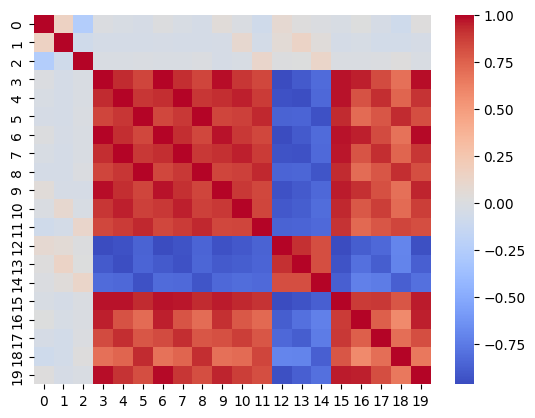

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(x.iloc[:,:20].corr(),cmap="coolwarm")
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [14]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x=pca.fit_transform(x_scaled)
print(x.shape)

(7352, 2)


/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ s

/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sa

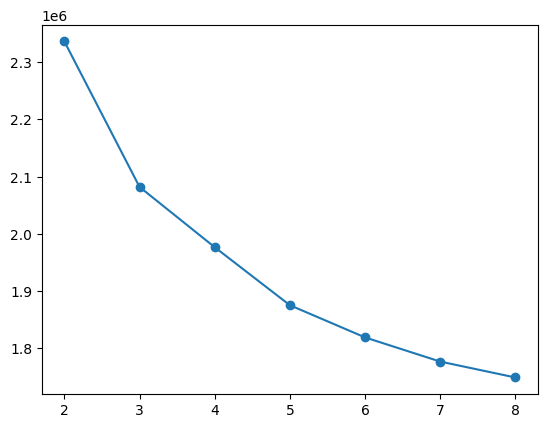

In [18]:
from sklearn.cluster import KMeans
wcss=[]
k=range(2,9)
for i in k:
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(k,wcss,marker='o')
plt.show()

/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sa

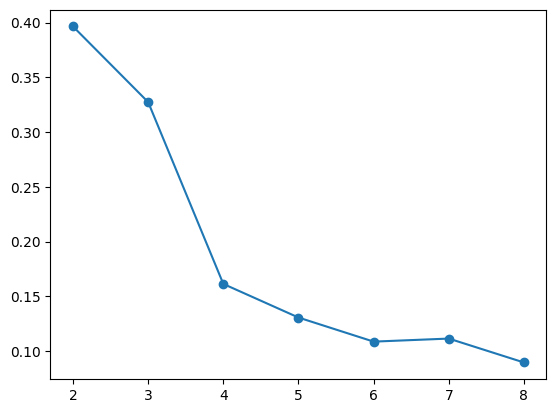

In [19]:
from sklearn.metrics import silhouette_score
scores=[]
for i in k:
    kmeans=KMeans(n_clusters=i,random_state=42)
    labels=kmeans.fit_predict(x_scaled)
    score=silhouette_score(x_scaled,labels)
    scores.append(score)

plt.plot(k,scores,marker="o")
plt.show()

/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sa

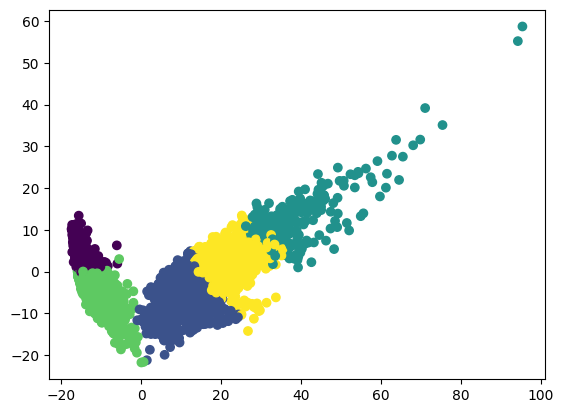

In [23]:
kmeans=KMeans(n_clusters=5,random_state=42)
label=kmeans.fit_predict(x_scaled)

plt.scatter(x[:,0],x[:,1],c=label)
plt.show()

In [25]:
DBSCAN?

Init signature:
DBSCAN(
    eps=0.5,
    *,
    min_samples=5,
    metric='euclidean',
    metric_params=None,
    algorithm='auto',
    leaf_size=30,
    p=None,
    n_jobs=None,
)
Docstring:     
Perform DBSCAN clustering from vector array or distance matrix.

DBSCAN - Density-Based Spatial Clustering of Applications with Noise.
Finds core samples of high density and expands clusters from them.
Good for data which contains clusters of similar density.

This implementation has a worst case memory complexity of :math:`O({n}^2)`,
which can occur when the `eps` param is large and `min_samples` is low,
while the original DBSCAN only uses linear memory.
For further details, see the Notes below.

Read more in the :ref:`User Guide <dbscan>`.

Parameters
----------
eps : float, default=0.5
    The maximum distance between two samples for one to be considered
    as in the neighborhood of the other. This is not a maximum bound
    on the distances of points within a cluster. This is the most
 

In [28]:
from sklearn.cluster import  DBSCAN
db=DBSCAN(eps=0.85,min_samples=10)
db_labels=db.fit_predict(x)

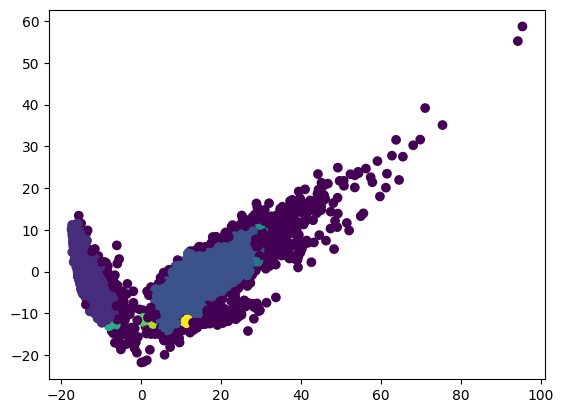

In [29]:
plt.scatter(x[:,0],x[:,1],c=db_labels)
plt.show()

In [33]:
from sklearn.cluster import AgglomerativeClustering

In [34]:
AgglomerativeClustering?

Init signature:
AgglomerativeClustering(
    n_clusters=2,
    *,
    metric='euclidean',
    memory=None,
    connectivity=None,
    compute_full_tree='auto',
    linkage='ward',
    distance_threshold=None,
    compute_distances=False,
)
Docstring:     
Agglomerative Clustering.

Recursively merges pair of clusters of sample data; uses linkage distance.

Read more in the :ref:`User Guide <hierarchical_clustering>`.

Parameters
----------
n_clusters : int or None, default=2
    The number of clusters to find. It must be ``None`` if
    ``distance_threshold`` is not ``None``.

metric : str or callable, default="euclidean"
    Metric used to compute the linkage. Can be "euclidean", "l1", "l2",
    "manhattan", "cosine", or "precomputed". If linkage is "ward", only
    "euclidean" is accepted. If "precomputed", a distance matrix is needed
    as input for the fit method. If connectivity is None, linkage is
    "single" and affinity is not "precomputed" any valid pairwise distance
    met

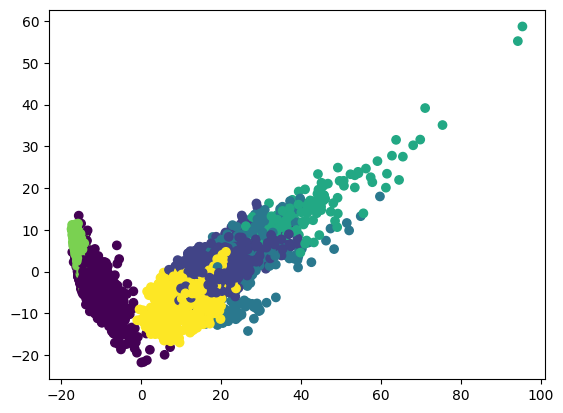

In [78]:
a=AgglomerativeClustering(n_clusters=6,linkage="ward")
a_labels=a.fit_predict(x_scaled)
plt.scatter(x[:,0],x[:,1],c=a_labels)
plt.show()

In [79]:
from sklearn.metrics import silhouette_score,calinski_harabasz_score,davies_bouldin_score,adjusted_rand_score,normalized_mutual_info_score

In [62]:
score=davies_bouldin_score(x,db_labels)

/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_lab/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWar

In [63]:
print(score)

1.7519549622385255


In [80]:
score=adjusted_rand_score(y.values.ravel(),a_labels)

In [81]:
print(score)

0.0


In [82]:
print(len(set(a_labels)))
print(len(set(y.values.ravel())))

6
7352
